In [1]:
# === Section 1: Setup & Imports ===
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal as scipy_signal
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve, auc
)
from sklearn.impute import SimpleImputer
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_selection import RFE
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import StackingClassifier
from sklearn.base import clone
from functions import load_subject_data, create_windows, stat_features, freq_features, eda_extra_features, extract_window_features

c:\Users\manuc\Documents\healthcare_final\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. Creation of Constants

In [2]:
# Constants
DATA_PATH = Path('WESAD')
SUBJECT_IDS = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]
LABEL_MAP = {1: 'Baseline', 2: 'Stress', 3: 'Amusement'}
WRIST_SAMPLING_RATES = {'ACC': 32, 'BVP': 64, 'EDA': 4, 'TEMP': 4}
LABEL_SAMPLING_RATE = 700
WINDOW_SIZE_SEC = 30  # 30-second windows
WINDOW_SHIFT_SEC = 5  # 5-second sliding step
VALID_LABELS = [1, 2, 3]
# Binary mapping: 0 = Non-Stress (baseline + amusement), 1 = Stress
BINARY_MAP = {1: 0, 2: 1, 3: 0}
BINARY_LABEL_NAMES = ['Non-Stress', 'Stress']

print(f"Subjects: {SUBJECT_IDS}")
print(f"Window size: {WINDOW_SIZE_SEC}s")

Subjects: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]
Window size: 30s


# 2. Data Loading & Exploration

In [3]:
# === Section: Data Loading ===
all_subjects_data = {}

for sid in SUBJECT_IDS:
    print(f"Loading S{sid}... ", end="")
    # Carichiamo il pkl (contiene sia wrist che chest)
    data = load_subject_data(DATA_PATH, sid)
    
    # [REQUISITO MUST]: Selezioniamo SOLO i dati del polso (Empatica E4)
    # Scartiamo i dati Respiban (chest) per rispettare le istruzioni
    wrist_only_data = {
        'signal': {'wrist': data['signal']['wrist']},
        'label': data['label']
    }
    
    all_subjects_data[sid] = wrist_only_data
    print("OK (Wrist data only)")

print(f"\nLoaded {len(all_subjects_data)} subjects successfully.")

# === Section: Preprocessing & Windowing ===
all_windows = {}
all_labels_dict = {}

print("Starting Windowing (Filters will be applied during feature extraction)...")

for sid in SUBJECT_IDS:
    # Chiamiamo create_windows con i parametri corretti (senza apply_filters)
    w, l = create_windows(
        all_subjects_data[sid], 
        WINDOW_SIZE_SEC, 
        WINDOW_SHIFT_SEC, 
        LABEL_SAMPLING_RATE, 
        WRIST_SAMPLING_RATES, 
        VALID_LABELS
    )
    
    all_windows[sid] = w
    all_labels_dict[sid] = l
    
    # Visualizziamo la distribuzione per ogni soggetto
    unique, counts = np.unique(l, return_counts=True)
    dist = ", ".join([f"{LABEL_MAP[int(u)]}={c}" for u, c in zip(unique, counts)])
    print(f"S{sid}: {len(w)} valid windows ({dist})")

total_windows = sum(len(v) for v in all_windows.values())
print(f"\nTotal preprocessed windows: {total_windows}")

Loading S2... OK (Wrist data only)
Loading S3... OK (Wrist data only)
Loading S4... OK (Wrist data only)
Loading S5... OK (Wrist data only)
Loading S6... OK (Wrist data only)
Loading S7... OK (Wrist data only)
Loading S8... OK (Wrist data only)
Loading S9... OK (Wrist data only)
Loading S10... OK (Wrist data only)
Loading S11... OK (Wrist data only)
Loading S13... OK (Wrist data only)
Loading S14... OK (Wrist data only)
Loading S15... OK (Wrist data only)
Loading S16... OK (Wrist data only)
Loading S17... OK (Wrist data only)

Loaded 15 subjects successfully.
Starting Windowing (Filters will be applied during feature extraction)...
S2: 413 valid windows (Baseline=225, Stress=119, Amusement=69)
S3: 419 valid windows (Baseline=224, Stress=124, Amusement=71)
S4: 422 valid windows (Baseline=228, Stress=123, Amusement=71)
S5: 432 valid windows (Baseline=236, Stress=125, Amusement=71)
S6: 430 valid windows (Baseline=232, Stress=127, Amusement=71)
S7: 429 valid windows (Baseline=234, Stress=1

In [4]:
sid = SUBJECT_IDS[0]
sample = all_subjects_data[sid]

print(f"Subject: S{sid}") 
print(f"Top-level keys: {list(sample.keys())}")
print(f"Signal keys: {list(sample['signal'].keys())}")
print(f"Wrist signal keys: {list(sample['signal']['wrist'].keys())}")

print(f"\nWrist signal shapes:")
for key, val in sample['signal']['wrist'].items():
    sr = WRIST_SAMPLING_RATES[key]
    duration = len(val) / sr
    print(f"  {key}: shape={val.shape}, rate={sr}Hz, duration={duration:.1f}s")

print(f"\nLabel shape: {sample['label'].shape}")
print(f"Label duration: {len(sample['label']) / LABEL_SAMPLING_RATE:.1f}s")

print(f"\nLabel distribution (S{sid}):")
unique, counts = np.unique(sample['label'], return_counts=True)
for u, c in zip(unique, counts):
    name = LABEL_MAP.get(int(u), f"Other({int(u)})")
    print(f"  {name}: {c} samples = {c/LABEL_SAMPLING_RATE:.1f}s")

Subject: S2
Top-level keys: ['signal', 'label']
Signal keys: ['wrist']
Wrist signal keys: ['ACC', 'BVP', 'EDA', 'TEMP']

Wrist signal shapes:
  ACC: shape=(194528, 3), rate=32Hz, duration=6079.0s
  BVP: shape=(389056, 1), rate=64Hz, duration=6079.0s
  EDA: shape=(24316, 1), rate=4Hz, duration=6079.0s
  TEMP: shape=(24316, 1), rate=4Hz, duration=6079.0s

Label shape: (4255300,)
Label duration: 6079.0s

Label distribution (S2):
  Other(0): 2142701 samples = 3061.0s
  Baseline: 800800 samples = 1144.0s
  Stress: 430500 samples = 615.0s
  Amusement: 253400 samples = 362.0s
  Other(4): 537599 samples = 768.0s
  Other(6): 45500 samples = 65.0s
  Other(7): 44800 samples = 64.0s


In [5]:
# Dataset statistics across all subjects
stats_rows = []
for sid in SUBJECT_IDS:
    labels = all_subjects_data[sid]['label'].flatten()
    for lv in VALID_LABELS:
        count = int(np.sum(labels == lv))
        stats_rows.append({
            'Subject': f'S{sid}',
            'Class': LABEL_MAP[lv],
            'Duration_s': round(count / LABEL_SAMPLING_RATE, 1)
        })

stats_df = pd.DataFrame(stats_rows)
pivot = stats_df.pivot_table(index='Subject', columns='Class', values='Duration_s')
print("Duration per class per subject (seconds):")
print(pivot.to_string())
print(f"\nTotal per class:\n{stats_df.groupby('Class')['Duration_s'].sum()}")


Duration per class per subject (seconds):
Class    Amusement  Baseline  Stress
Subject                             
S10          372.0    1180.0   725.0
S11          368.0    1180.0   680.0
S13          382.0    1180.0   664.0
S14          372.0    1180.0   675.0
S15          372.0    1175.0   686.0
S16          368.0    1180.0   673.0
S17          372.0    1181.0   723.0
S2           362.0    1144.0   615.0
S3           375.0    1140.0   640.0
S4           372.0    1158.0   635.0
S5           374.0    1198.0   645.0
S6           372.0    1180.0   650.0
S7           372.0    1186.0   640.0
S8           370.0    1169.0   670.0
S9           372.0    1180.0   645.0

Total per class:
Class
Amusement     5575.0
Baseline     17611.0
Stress        9966.0
Name: Duration_s, dtype: float64


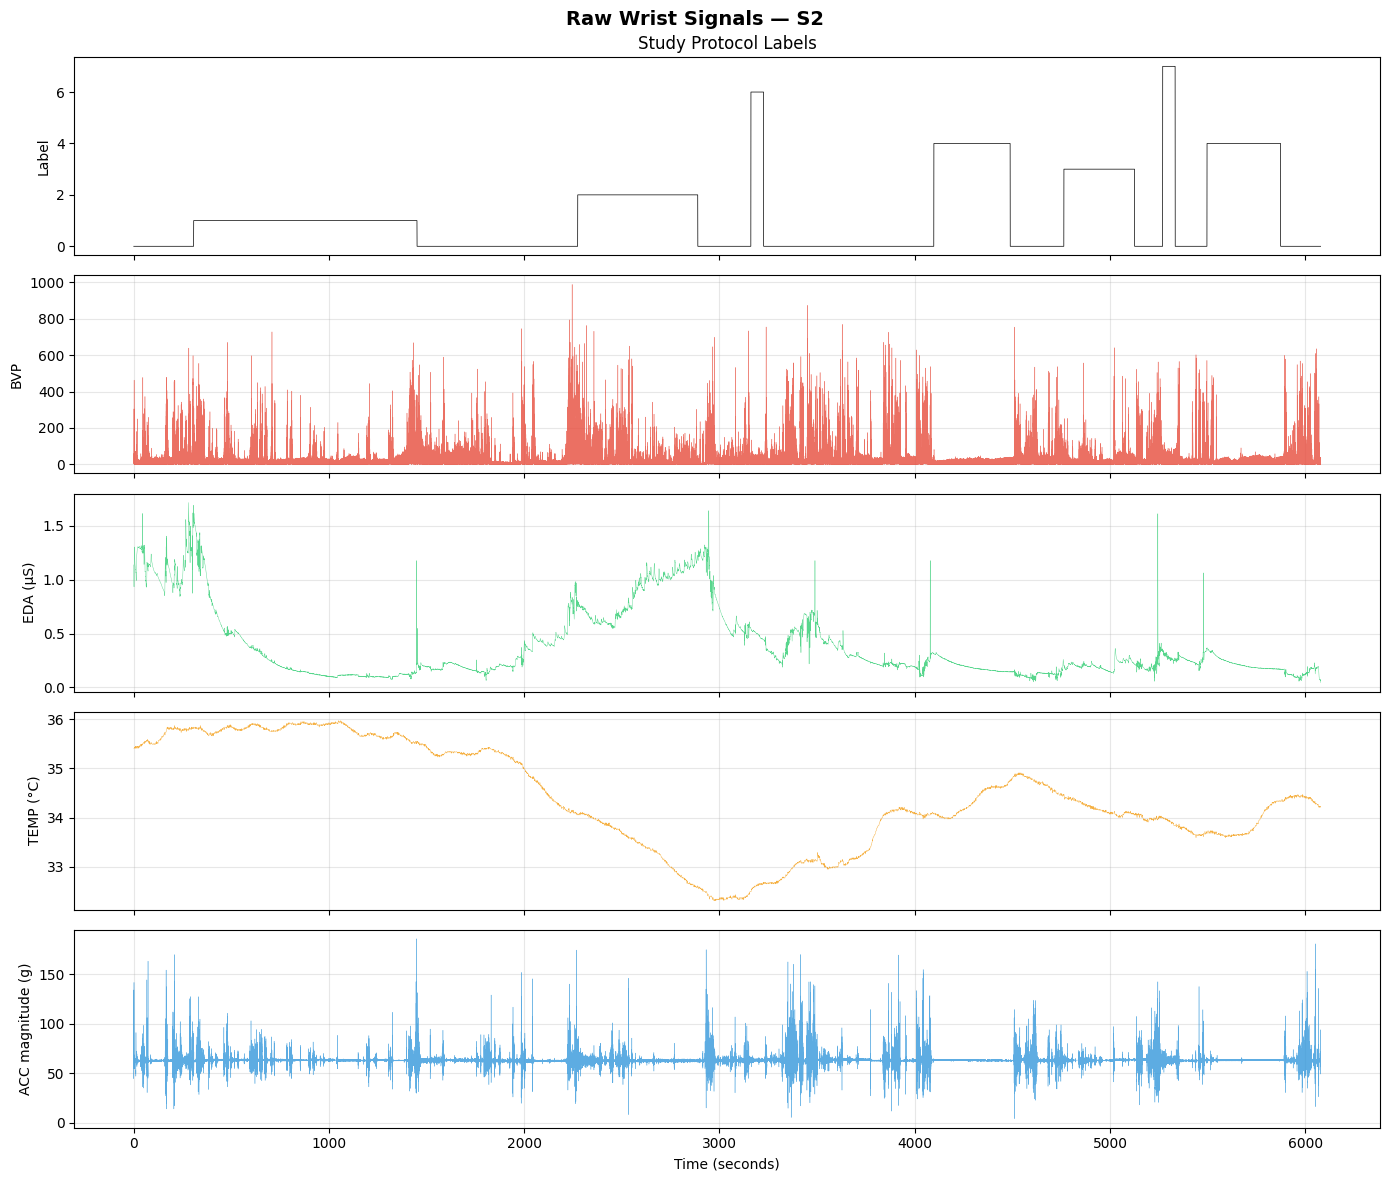

In [6]:
# Visualize raw wrist signals for one subject 
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
fig.suptitle(f"Raw Wrist Signals — S{SUBJECT_IDS[0]}", fontsize=14, fontweight='bold')

wrist = sample['signal']['wrist']
labels = sample['label'].flatten()

# Plot labels
t_labels = np.arange(len(labels)) / LABEL_SAMPLING_RATE
axes[0].plot(t_labels, labels, color='black', linewidth=0.5)
axes[0].set_ylabel('Label')
axes[0].set_title('Study Protocol Labels')

# Plot each wrist signal
signal_list = [
    ('BVP', 'BVP', '#e74c3c'),
    ('EDA', 'EDA (μS)', '#2ecc71'),
    ('TEMP', 'TEMP (°C)', '#f39c12'),
    ('ACC', 'ACC magnitude (g)', '#3498db'),
]

for i, (key, ylabel, color) in enumerate(signal_list):
    ax = axes[i + 1]
    sr = WRIST_SAMPLING_RATES[key]
    data = wrist[key]
    if data.ndim > 1:
        data = np.linalg.norm(data, axis=1)
    else:
        data = data.flatten()
    t = np.arange(len(data)) / sr
    ax.plot(t, data, color=color, linewidth=0.3, alpha=0.8)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (seconds)')
plt.tight_layout()
plt.show()


# Section 3: Preprocessing & Windowing

Segment all wrist signals into **5-second** fixed windows. Each window gets a label via **majority vote** from the 700 Hz label stream. Windows with ambiguous labels (majority < 80%) or invalid labels (0, 4–7) are discarded.

Features are extracted at each signal's **native sampling rate** to preserve information.


In [7]:
# === Process all subjects ===
all_windows = {}
all_labels_dict = {}

for sid in SUBJECT_IDS:
    w, l = create_windows(all_subjects_data[sid], WINDOW_SIZE_SEC, WINDOW_SHIFT_SEC, LABEL_SAMPLING_RATE, WRIST_SAMPLING_RATES, VALID_LABELS)
    all_windows[sid] = w
    all_labels_dict[sid] = l
    unique, counts = np.unique(l, return_counts=True)
    dist = ", ".join([f"{LABEL_MAP[int(u)]}={c}" for u, c in zip(unique, counts)])
    print(f"S{sid}: {len(w)} windows ({dist})")

total = sum(len(v) for v in all_windows.values())
print(f"\nTotal windows: {total}")


S2: 413 windows (Baseline=225, Stress=119, Amusement=69)
S3: 419 windows (Baseline=224, Stress=124, Amusement=71)
S4: 422 windows (Baseline=228, Stress=123, Amusement=71)
S5: 432 windows (Baseline=236, Stress=125, Amusement=71)
S6: 430 windows (Baseline=232, Stress=127, Amusement=71)
S7: 429 windows (Baseline=234, Stress=124, Amusement=71)
S8: 430 windows (Baseline=230, Stress=130, Amusement=70)
S9: 429 windows (Baseline=233, Stress=125, Amusement=71)
S10: 444 windows (Baseline=232, Stress=141, Amusement=71)
S11: 435 windows (Baseline=233, Stress=132, Amusement=70)
S13: 435 windows (Baseline=232, Stress=130, Amusement=73)
S14: 435 windows (Baseline=232, Stress=132, Amusement=71)
S15: 436 windows (Baseline=232, Stress=134, Amusement=70)
S16: 433 windows (Baseline=232, Stress=131, Amusement=70)
S17: 444 windows (Baseline=232, Stress=141, Amusement=71)

Total windows: 6466


# Section 4 — Feature Extraction


For each 5-second window, extract **time-domain** and **frequency-domain** features from all wrist signals:
- **Statistical**: mean, std, min, max, median, range, skewness, kurtosis, RMS, mean absolute deviation, sum of absolute differences
- **Frequency**: total power, dominant frequency, spectral entropy (via Welch's method)
- **EDA-specific**: number of peaks, mean peak height, derivative statistics

In [8]:
# Build the feature matrix 
print("Extracting features from all windows...")

feature_rows = []
label_rows = []
group_rows = []

for sid in SUBJECT_IDS:
    n = len(all_windows[sid])
    print(f"  S{sid}: {n} windows...", end=" ")
    for window, label in zip(all_windows[sid], all_labels_dict[sid]):
        feature_rows.append(extract_window_features(window, WRIST_SAMPLING_RATES))
        label_rows.append(BINARY_MAP[label])
        group_rows.append(sid)
    print("done")

X = pd.DataFrame(feature_rows)
y = np.array(label_rows)
groups = np.array(group_rows)

# Clean NaN/Inf
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"\nFeature matrix: {X.shape[0]} samples X {X.shape[1]} features")
print(f"Non-Stress: {np.sum(y == 0)}, Stress: {np.sum(y == 1)}")
print(f"\nFeatures ({X.shape[1]}):")
for i, c in enumerate(X.columns, 1):
    print(f"  {i:3d}. {c}")


Extracting features from all windows...
  S2: 413 windows... done
  S3: 419 windows... done
  S4: 422 windows... done
  S5: 432 windows... done
  S6: 430 windows... done
  S7: 429 windows... done
  S8: 430 windows... done
  S9: 429 windows... done
  S10: 444 windows... done
  S11: 435 windows... done
  S13: 435 windows... done
  S14: 435 windows... done
  S15: 436 windows... done
  S16: 433 windows... done
  S17: 444 windows... done

Feature matrix: 6466 samples X 99 features
Non-Stress: 4528, Stress: 1938

Features (99):
    1. ACC_x_mean
    2. ACC_x_std
    3. ACC_x_min
    4. ACC_x_max
    5. ACC_x_median
    6. ACC_x_range
    7. ACC_x_skew
    8. ACC_x_kurtosis
    9. ACC_x_rms
   10. ACC_x_mad
   11. ACC_x_sad
   12. ACC_x_total_power
   13. ACC_x_dom_freq
   14. ACC_x_spectral_entropy
   15. ACC_y_mean
   16. ACC_y_std
   17. ACC_y_min
   18. ACC_y_max
   19. ACC_y_median
   20. ACC_y_range
   21. ACC_y_skew
   22. ACC_y_kurtosis
   23. ACC_y_rms
   24. ACC_y_mad
   25. ACC_y_s

### Commentary on the Feature Extraction Results

This code block represents the transition from raw physiological signals to the final dataset, ready for Machine Learning. Here is a breakdown of what was done and the results obtained:

*   **Building Matrix X:** For each subject, the algorithm examined the previously created time windows and extracted 99 mathematical features (e.g., mean, standard deviation, frequency power, entropy) using the `extract_window_features` function[cite: 1, 3]. The result is a DataFrame `X` containing 6466 samples (rows) and 99 columns[cite: 3].
*   **Binary Mapping (Array y):** The original WESAD protocol labels were converted into a binary classification problem using the `BINARY_MAP` variable[cite: 3]. The "Baseline" (1) and "Amusement" (3) states were merged into class **0 (Non-Stress)**, while the "Stress" condition (2) became class **1 (Stress)**[cite: 3].
*   **Preparation for LOSO (Array groups):** The `groups` array stores the subject ID (`sid`) associated with each individual window[cite: 3]. This array is the foundation that allows us to correctly execute the Leave-One-Subject-Out Cross-Validation, ensuring that the data of a subject used for testing never ends up in the training set[cite: 2, 3].
*   **Handling Anomalous Data:** The line `X.replace([np.inf, -np.inf], np.nan).fillna(0)` is a safety measure[cite: 3]. It transforms any infinite or missing values (which can occasionally occur during divisions when calculating frequency features) into zeros, preventing the ML models from crashing[cite: 3].
*   **Class Imbalance Analysis:** The output reveals a clear imbalance: **4528 Non-Stress samples versus 1938 Stress samples**[cite: 3]. This reflects the actual structure of the experimental protocol (the baseline and relaxation phases simply last longer than the acute stress phase). This imbalance justifies the use of the `class_weight='balanced'` parameter in our Logistic Regression and reminds us to evaluate performance using the F1-Score rather than just simple Accuracy[cite: 3].
*   **Analyzed Subjects:** As noted in the logs, the subjects start from S2 and skip S1 and S12[cite: 3]. This aligns with the original WESAD dataset, where data for S1 and S12 were discarded due to sensor malfunctions[cite: 2].

# Section 5. Feature Analysis

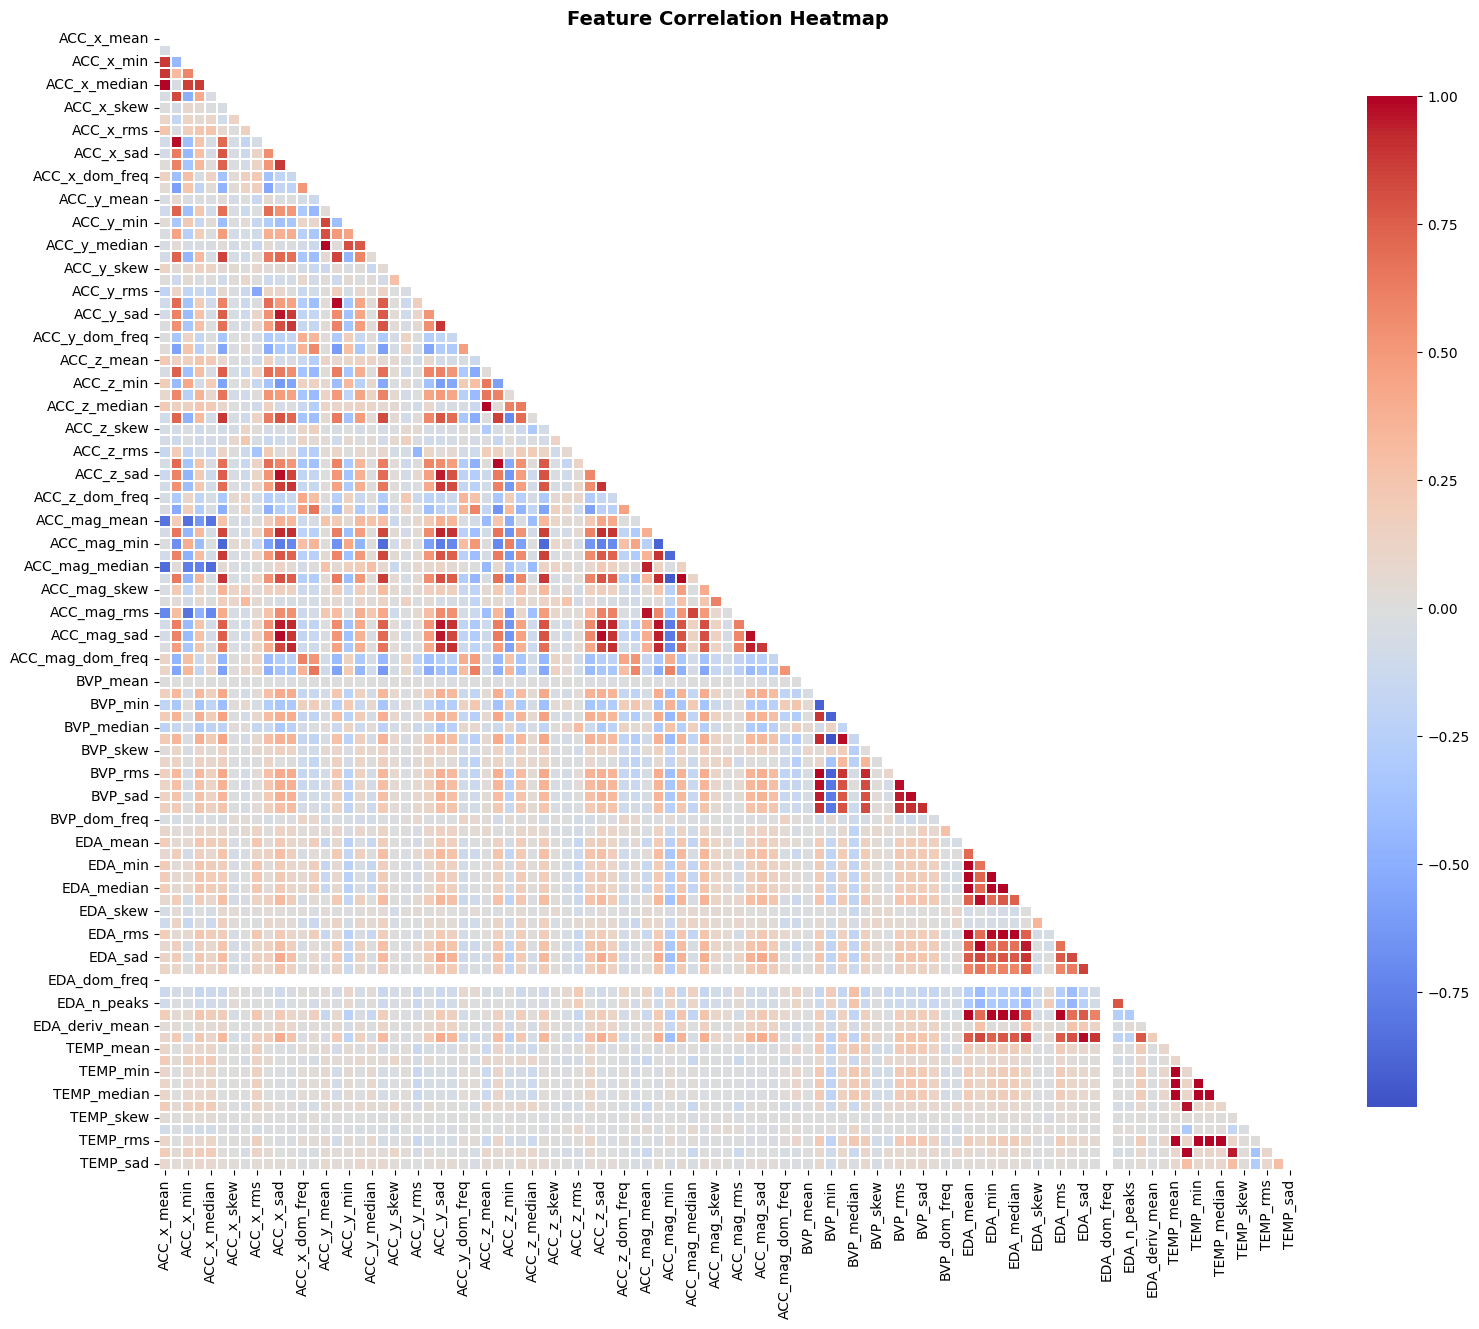

In [9]:
# Correlation heatmap
plt.figure(figsize=(16, 14))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=0.3, annot=False,
            cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

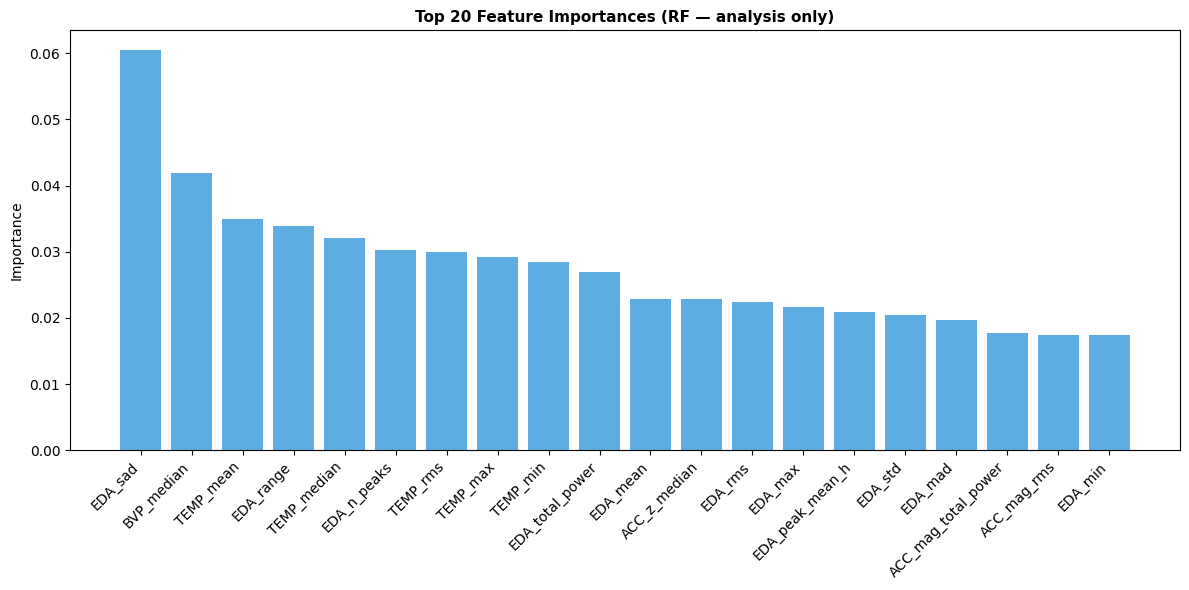

In [10]:
# Feature importance (quick RF, not a final model)
scaler_tmp = StandardScaler()
X_tmp = scaler_tmp.fit_transform(X)

rf_analysis = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_analysis.fit(X_tmp, y)

importances = rf_analysis.feature_importances_
top_idx = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(12, 6))
plt.bar(range(20), importances[top_idx], color='#3498db', alpha=0.8)
plt.xticks(range(20), [X.columns[i] for i in top_idx], rotation=45, ha='right')
plt.title('Top 20 Feature Importances (RF — analysis only)',
          fontsize=11, fontweight='bold')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

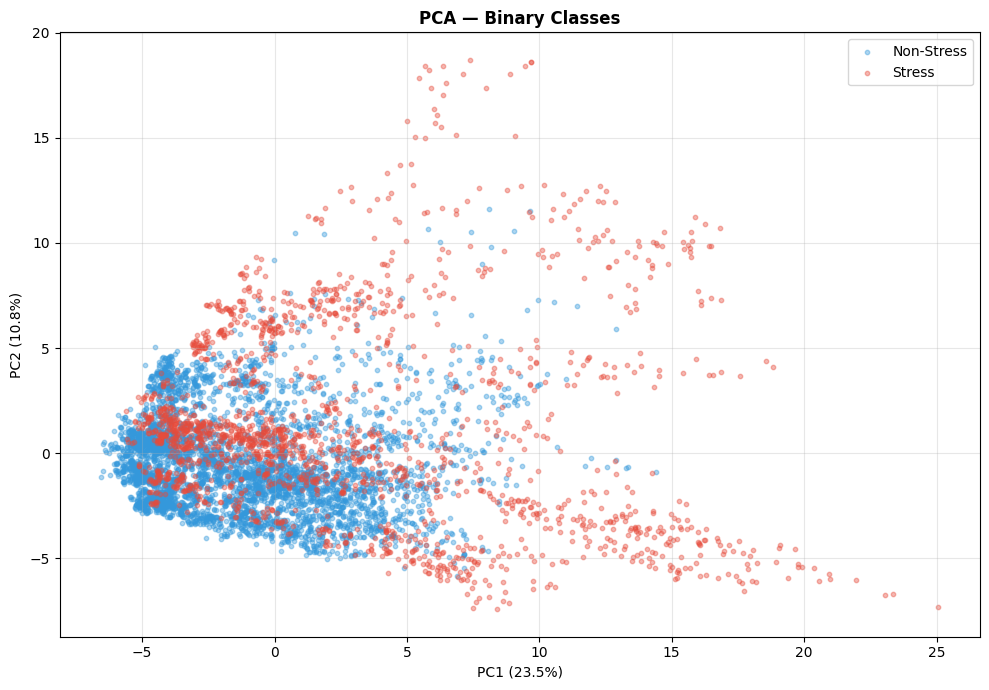

Explained variance (2 PCs): 34.3%


In [11]:
# PCA Visualization
scaler_pca = StandardScaler()
X_pca_in = scaler_pca.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_pca_in)

plt.figure(figsize=(10, 7))
for lv, color, name in zip([0, 1], ['#3498db', '#e74c3c'], BINARY_LABEL_NAMES):
    m = y == lv
    plt.scatter(X_pca[m, 0], X_pca[m, 1], c=color, label=name, alpha=0.4, s=10)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA — Binary Classes', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Explained variance (2 PCs): {sum(pca.explained_variance_ratio_)*100:.1f}%")


# Section 6. Model Development

Models chosen to be **different from the original WESAD paper** (which used DT, RF, AdaBoost, LDA, kNN):
1. **Logistic Regression**
2. **SVM** (RBF kernel)
3. **Gradient Boosting** (sklearn)
4. **MLP** (Multi-Layer Perceptron)

Cross Validation employed for the models is: 

**Leave-One-Subject-Out**: train on 14 subjects, test on 1. Ensures subject-independent evaluation.

In [12]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42, class_weight='balanced'),
    'SVM (RBF)': SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(128, 64), max_iter=500,
        early_stopping=True, validation_fraction=0.1, random_state=42
    ),
}


In [13]:
# LOSO CV 
logo = LeaveOneGroupOut()
results = {name: {'y_true': [], 'y_pred': [], 'y_prob': [], 'subjects': []}
           for name in models}

n_folds = logo.get_n_splits(X, y, groups)
print(f"Running LOSO Cross-Validation ({n_folds} folds)")
print(f"Features: {X.shape[1]}  |  Samples: {X.shape[0]}")
print("=" * 70)

for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups)):
    test_subj = groups[test_idx[0]]
    print(f"\nFold {fold+1}/{n_folds}: test on S{test_subj} "
          f"(train={len(train_idx)}, test={len(test_idx)})")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    imputer = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp = imputer.transform(X_test)

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train_imp)
    X_te = scaler.transform(X_test_imp)

    for mname, model in models.items():
        m = clone(model)
        m.fit(X_tr, y_train)
        preds = m.predict(X_te)
        probs = m.predict_proba(X_te)[:, 1]

        results[mname]['y_true'].extend(y_test)
        results[mname]['y_pred'].extend(preds)
        results[mname]['y_prob'].extend(probs)
        results[mname]['subjects'].extend([test_subj] * len(y_test))

        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds)
        print(f"  {mname}: Acc={acc:.3f}, F1={f1:.3f}")

print("\n" + "=" * 70)
print("LOSO Cross-Validation complete!")

Running LOSO Cross-Validation (15 folds)
Features: 99  |  Samples: 6466

Fold 1/15: test on S2 (train=6053, test=413)
  Logistic Regression: Acc=0.678, F1=0.332
  SVM (RBF): Acc=0.843, F1=0.739
  Gradient Boosting: Acc=0.920, F1=0.839
  MLP: Acc=0.785, F1=0.594

Fold 2/15: test on S3 (train=6047, test=419)
  Logistic Regression: Acc=0.699, F1=0.613
  SVM (RBF): Acc=0.821, F1=0.667
  Gradient Boosting: Acc=0.893, F1=0.846
  MLP: Acc=0.857, F1=0.787

Fold 3/15: test on S4 (train=6044, test=422)
  Logistic Regression: Acc=0.995, F1=0.992
  SVM (RBF): Acc=0.976, F1=0.958
  Gradient Boosting: Acc=0.948, F1=0.904
  MLP: Acc=0.988, F1=0.979

Fold 4/15: test on S5 (train=6034, test=432)
  Logistic Regression: Acc=0.875, F1=0.803
  SVM (RBF): Acc=0.824, F1=0.670
  Gradient Boosting: Acc=0.838, F1=0.628
  MLP: Acc=0.919, F1=0.876

Fold 5/15: test on S6 (train=6036, test=430)
  Logistic Regression: Acc=0.921, F1=0.867
  SVM (RBF): Acc=0.602, F1=0.266
  Gradient Boosting: Acc=0.837, F1=0.784
  MLP

# Section 7. Evaluation

In [14]:
# Overall metrics
print("=" * 70)
print("OVERALL MODEL COMPARISON")
print("=" * 70)

comparison = []
for mname in models:
    yt = np.array(results[mname]['y_true'])
    yp = np.array(results[mname]['y_pred'])

    row = {
        'Model': mname,
        'Accuracy': round(accuracy_score(yt, yp), 4),
        'Precision': round(precision_score(yt, yp), 4),
        'Recall': round(recall_score(yt, yp), 4),
        'F1-Score': round(f1_score(yt, yp), 4),
    }
    comparison.append(row)
    print(f"\n--- {mname} ---")
    print(classification_report(yt, yp, target_names=BINARY_LABEL_NAMES))

comp_df = pd.DataFrame(comparison)
print("\nSummary Table:")
print(comp_df.to_string(index=False))


OVERALL MODEL COMPARISON

--- Logistic Regression ---
              precision    recall  f1-score   support

  Non-Stress       0.92      0.90      0.91      4528
      Stress       0.78      0.82      0.80      1938

    accuracy                           0.88      6466
   macro avg       0.85      0.86      0.85      6466
weighted avg       0.88      0.88      0.88      6466


--- SVM (RBF) ---
              precision    recall  f1-score   support

  Non-Stress       0.87      0.90      0.89      4528
      Stress       0.75      0.70      0.72      1938

    accuracy                           0.84      6466
   macro avg       0.81      0.80      0.80      6466
weighted avg       0.84      0.84      0.84      6466


--- Gradient Boosting ---
              precision    recall  f1-score   support

  Non-Stress       0.89      0.92      0.91      4528
      Stress       0.80      0.74      0.77      1938

    accuracy                           0.87      6466
   macro avg       0.85     

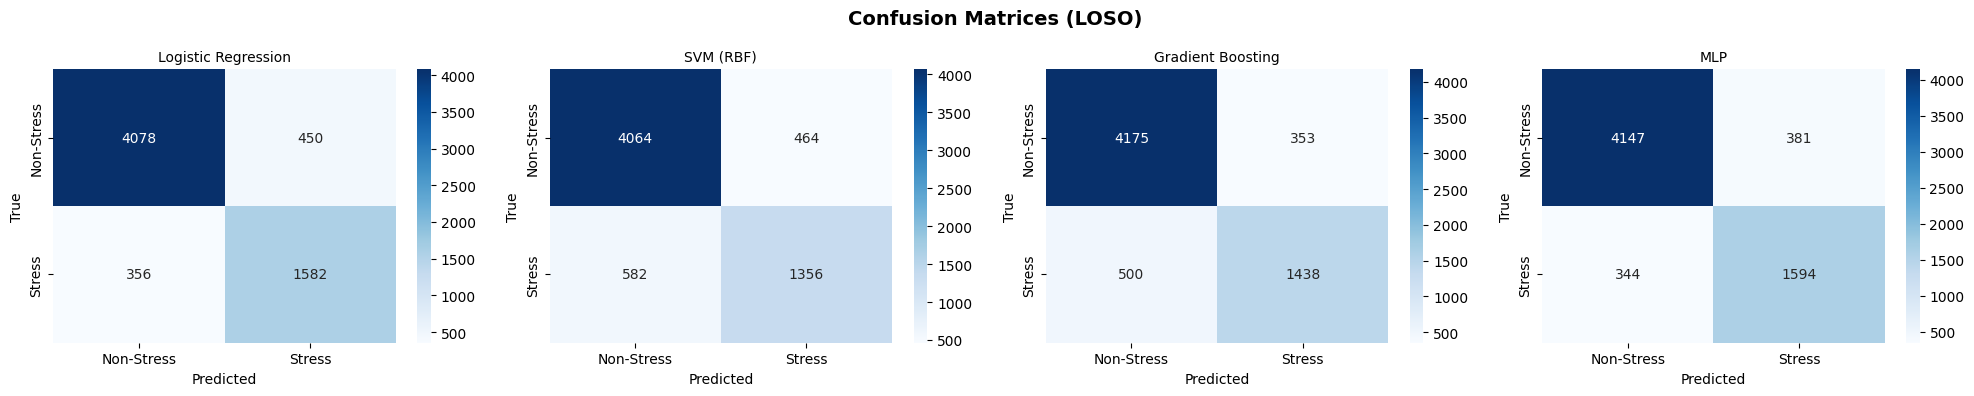

In [15]:
# Confusion matrices 
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4))
fig.suptitle('Confusion Matrices (LOSO)', fontsize=14, fontweight='bold')

for idx, mname in enumerate(models):
    yt = np.array(results[mname]['y_true'])
    yp = np.array(results[mname]['y_pred'])
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=BINARY_LABEL_NAMES, yticklabels=BINARY_LABEL_NAMES)
    axes[idx].set_title(mname, fontsize=10)
    axes[idx].set_ylabel('True')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.show()


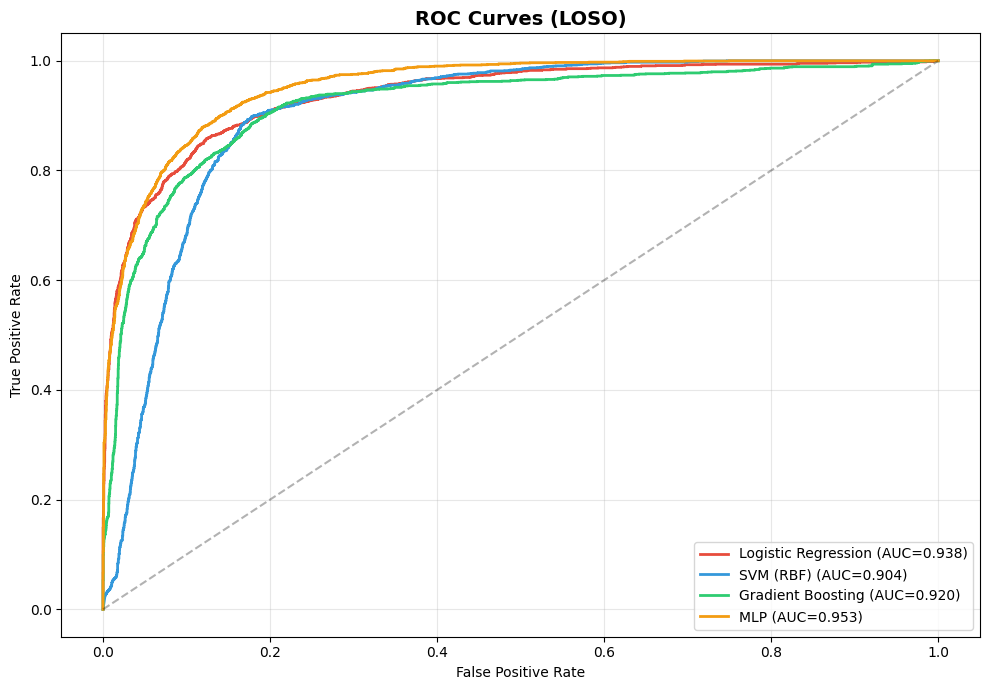

In [16]:
# ROC Curves
plt.figure(figsize=(10, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for mname, color in zip(models, colors):
    yt = np.array(results[mname]['y_true'])
    yp = np.array(results[mname]['y_prob'])
    fpr, tpr, _ = roc_curve(yt, yp)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{mname} (AUC={roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (LOSO)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Best model by F1: MLP

Subject  Accuracy     F1  N_samples  Stress_ratio
     S2    0.7845 0.5936        413         0.288
     S3    0.8568 0.7872        419         0.296
     S4    0.9882 0.9793        422         0.291
     S5    0.9190 0.8763        432         0.289
     S6    0.8047 0.7162        430         0.295
     S7    0.6760 0.6408        429         0.289
     S8    0.9558 0.9212        430         0.302
     S9    0.7879 0.4277        429         0.291
    S10    0.9459 0.9104        444         0.318
    S11    0.9908 0.9851        435         0.303
    S13    0.9563 0.9319        435         0.299
    S14    0.9057 0.8161        435         0.303
    S15    0.8739 0.7826        436         0.307
    S16    0.9677 0.9493        433         0.303
    S17    0.8964 0.8067        444         0.318


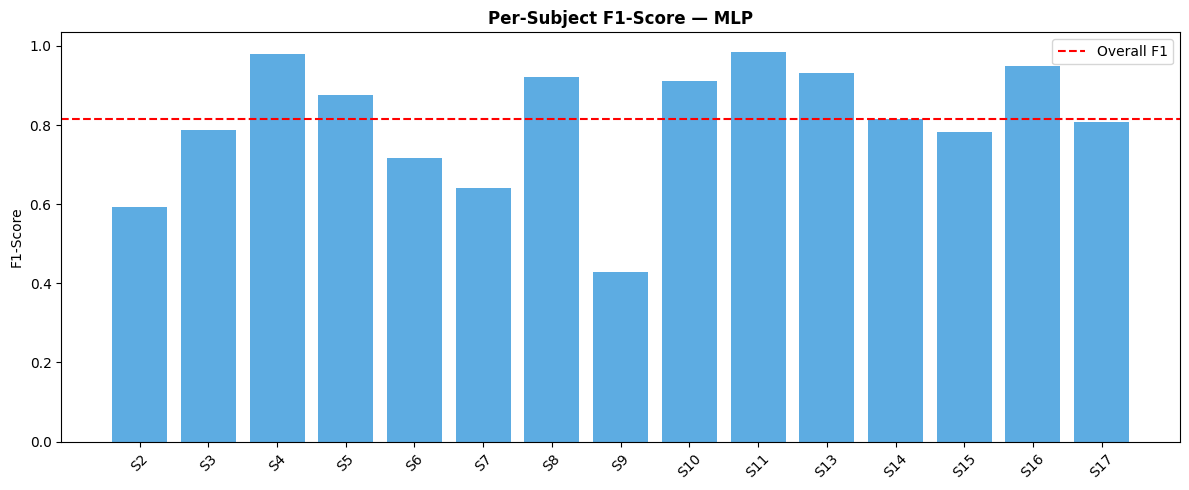

In [17]:
# Per-subject performance (best model) 
best_model = comp_df.loc[comp_df['F1-Score'].idxmax(), 'Model']
print(f"Best model by F1: {best_model}\n")

per_subj = []
for sid in SUBJECT_IDS:
    mask = np.array(results[best_model]['subjects']) == sid
    yt = np.array(results[best_model]['y_true'])[mask]
    yp = np.array(results[best_model]['y_pred'])[mask]
    per_subj.append({
        'Subject': f'S{sid}',
        'Accuracy': round(accuracy_score(yt, yp), 4),
        'F1': round(f1_score(yt, yp, zero_division=0), 4),
        'N_samples': len(yt),
        'Stress_ratio': round(np.mean(yt), 3),
    })

per_subj_df = pd.DataFrame(per_subj)
print(per_subj_df.to_string(index=False))

# Plot per-subject F1
plt.figure(figsize=(12, 5))
plt.bar(per_subj_df['Subject'], per_subj_df['F1'], color='#3498db', alpha=0.8)
plt.axhline(y=comp_df.loc[comp_df['Model'] == best_model, 'F1-Score'].values[0],
            color='red', linestyle='--', label='Overall F1')
plt.ylabel('F1-Score')
plt.title(f'Per-Subject F1-Score — {best_model}', fontsize=12, fontweight='bold')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


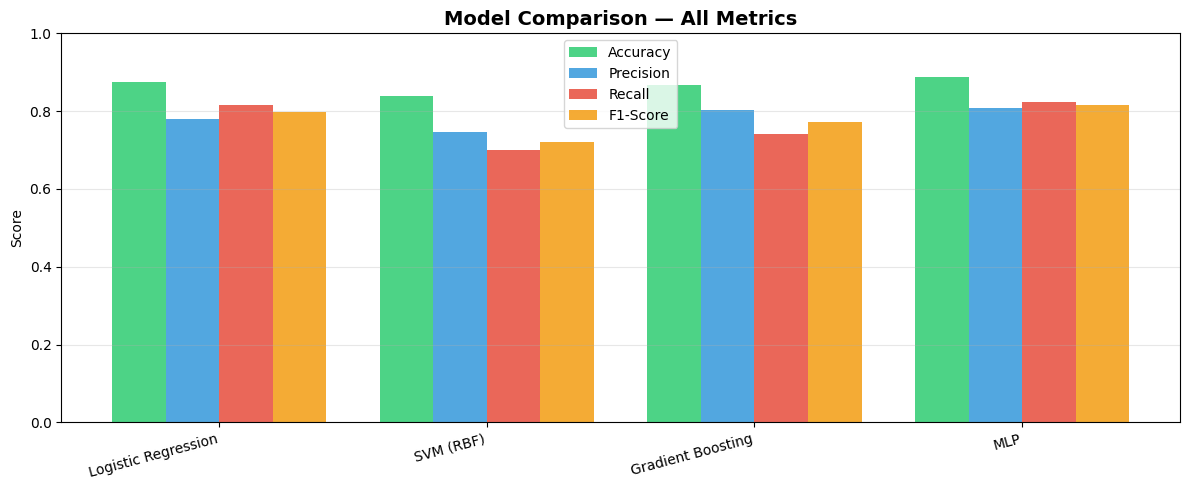

In [18]:
# Final model comparison bar chart
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(comp_df))
width = 0.2
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors_bar = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

for i, (metric, color) in enumerate(zip(metrics, colors_bar)):
    ax.bar(x + i * width, comp_df[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(comp_df['Model'], rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()



## 7.2 Stacking

In [19]:
# POST-HOC STACKING ENSEMBLE (Using already computed results) 

print("\n" + "=" * 70)
print("POST-HOC STACKING ENSEMBLE")
print("=" * 70)

# The new ‘features’ are the probabilities predicted by the four base models.
meta_features = {}
for mname in models.keys():
    meta_features[mname] = results[mname]['y_prob']

X_meta = pd.DataFrame(meta_features)

first_model_name = list(models.keys())[0]
y_meta = np.array(results[first_model_name]['y_true'])
groups_meta = np.array(results[first_model_name]['subjects'])

# 2. Use Logistic Regression as Meta Model
meta_model = LogisticRegression(random_state=42, class_weight='balanced')

# 3. LOSO on the Meta-Model only 
logo_meta = LeaveOneGroupOut()
y_true_stacking = []
y_pred_stacking = []

for train_idx, test_idx in logo_meta.split(X_meta, y_meta, groups_meta):
    X_tr_meta, X_te_meta = X_meta.iloc[train_idx], X_meta.iloc[test_idx]
    y_tr_meta, y_te_meta = y_meta[train_idx], y_meta[test_idx]
    
    meta_model.fit(X_tr_meta, y_tr_meta)
    preds_meta = meta_model.predict(X_te_meta)
    
    y_true_stacking.extend(y_te_meta)
    y_pred_stacking.extend(preds_meta)

# 4. final results of the stacking
acc_stack = accuracy_score(y_true_stacking, y_pred_stacking)
f1_stack = f1_score(y_true_stacking, y_pred_stacking)

print(f"Stacking Ensemble: Accuracy = {acc_stack:.4f}, F1-Score = {f1_stack:.4f}\n")
print("--- Stacking Ensemble Classification Report ---")
print(classification_report(y_true_stacking, y_pred_stacking, target_names=BINARY_LABEL_NAMES))

# result to previous comparisons
row_stack = {
    'Model': 'Stacking Ensemble',
    'Accuracy': round(acc_stack, 4),
    'Precision': round(precision_score(y_true_stacking, y_pred_stacking), 4),
    'Recall': round(recall_score(y_true_stacking, y_pred_stacking), 4),
    'F1-Score': round(f1_stack, 4),
}
comp_df = pd.concat([comp_df, pd.DataFrame([row_stack])], ignore_index=True)

print("\nUpdated Summary Table (including Stacking):")
print(comp_df.to_string(index=False))


POST-HOC STACKING ENSEMBLE
Stacking Ensemble: Accuracy = 0.8766, F1-Score = 0.8050

--- Stacking Ensemble Classification Report ---
              precision    recall  f1-score   support

  Non-Stress       0.93      0.89      0.91      4528
      Stress       0.76      0.85      0.80      1938

    accuracy                           0.88      6466
   macro avg       0.85      0.87      0.86      6466
weighted avg       0.88      0.88      0.88      6466


Updated Summary Table (including Stacking):
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.8753     0.7785  0.8163    0.7970
          SVM (RBF)    0.8382     0.7451  0.6997    0.7217
  Gradient Boosting    0.8681     0.8029  0.7420    0.7713
                MLP    0.8879     0.8071  0.8225    0.8147
  Stacking Ensemble    0.8766     0.7646  0.8498    0.8050


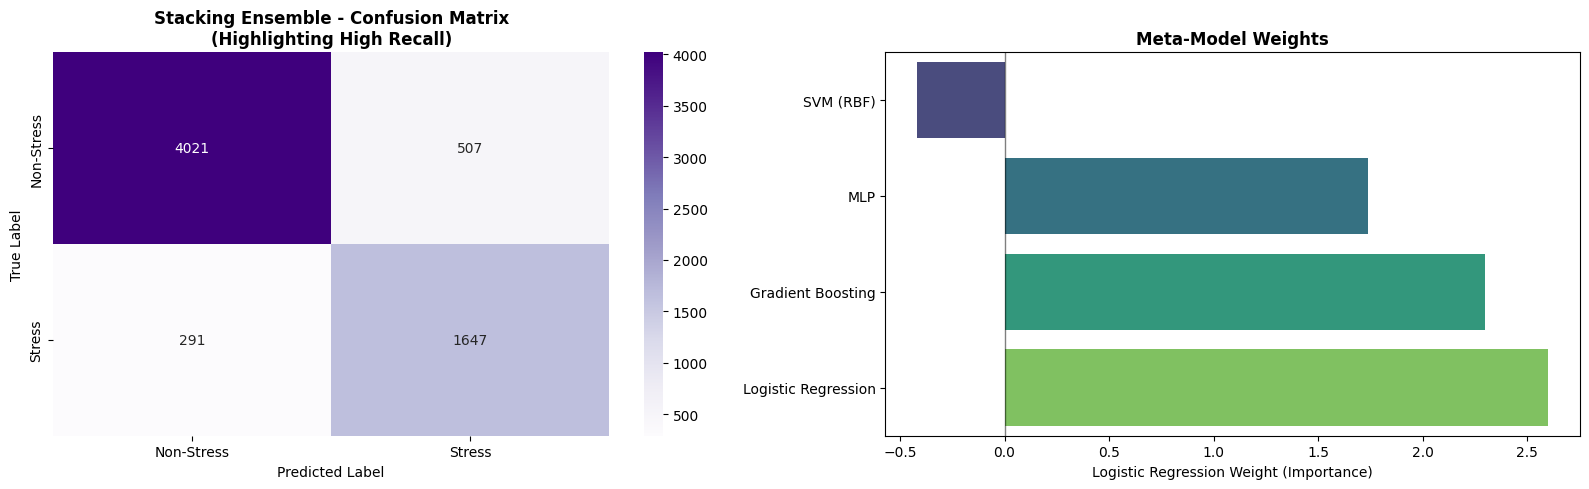

In [20]:
# STACKING VISUALIZATIONS

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# PLOT 1: Confusion Matrix Stacking 
cm_stack = confusion_matrix(y_true_stacking, y_pred_stacking)
sns.heatmap(cm_stack, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=BINARY_LABEL_NAMES, yticklabels=BINARY_LABEL_NAMES)
axes[0].set_title('Stacking Ensemble - Confusion Matrix\n(Highlighting High Recall)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# PLOT 2: Meta-Weights
meta_model_explainer = LogisticRegression(random_state=42, class_weight='balanced')
meta_model_explainer.fit(X_meta, y_meta)

weights = meta_model_explainer.coef_[0]
model_names = list(X_meta.columns)

sorted_idx = np.argsort(weights)
sorted_weights = weights[sorted_idx]
sorted_names = [model_names[i] for i in sorted_idx]

sns.barplot(x=sorted_weights, y=sorted_names, palette='viridis', ax=axes[1])
axes[1].axvline(0, color='black', linewidth=1, alpha=0.5)
axes[1].set_title('Meta-Model Weights', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Logistic Regression Weight (Importance)')

plt.tight_layout()
plt.show()

# Section 8. Feature Relevance Analysis
As part of the project requirements, we analyze which features are driving the predictions.

In [21]:
print("Training final Gradient Boosting model to analyze feature importance...")
final_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
imputer_final = SimpleImputer(strategy='median')
scaler_final = StandardScaler()
X_imp = imputer_final.fit_transform(X)
X_scaled = scaler_final.fit_transform(X_imp)
final_model.fit(X_scaled, y)

Training final Gradient Boosting model to analyze feature importance...


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

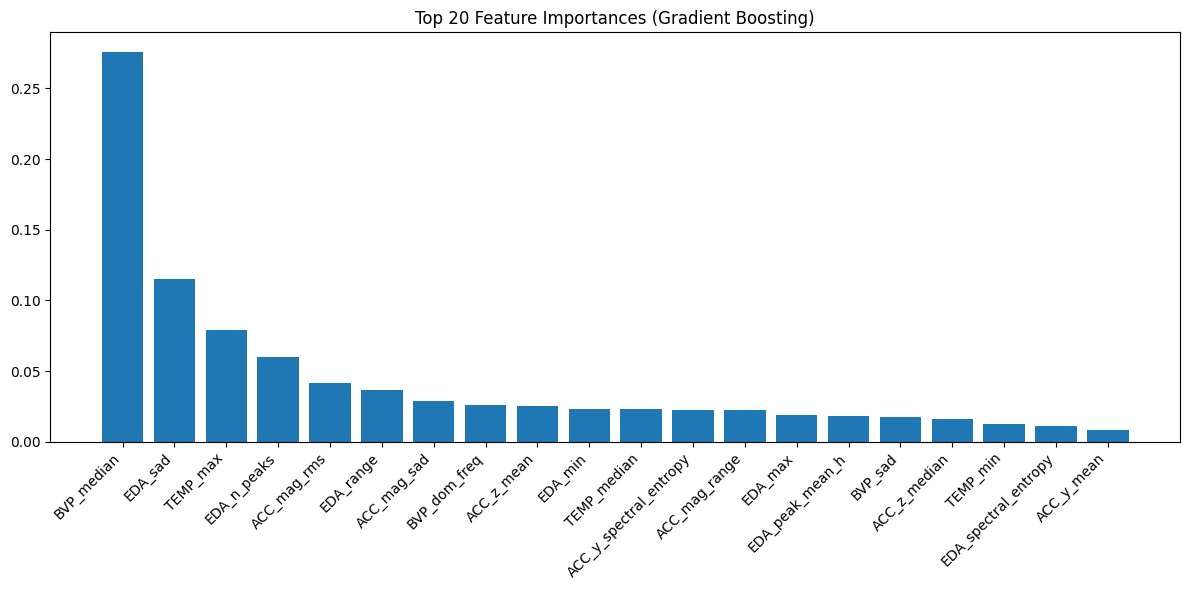

In [22]:
# 1. Traditional Feature Importance
importances = final_model.feature_importances_
indices = np.argsort(importances)[::-1]
top_feature_idx = indices[0]
top_feature_name = X.columns[top_feature_idx]

plt.figure(figsize=(12, 6))
plt.title("Top 20 Feature Importances (Gradient Boosting)")
plt.bar(range(20), importances[indices[:20]], align="center")
plt.xticks(range(20), X.columns[indices[:20]], rotation=45, ha='right')
plt.tight_layout()
plt.show()


Calculating SHAP values for global explainability...


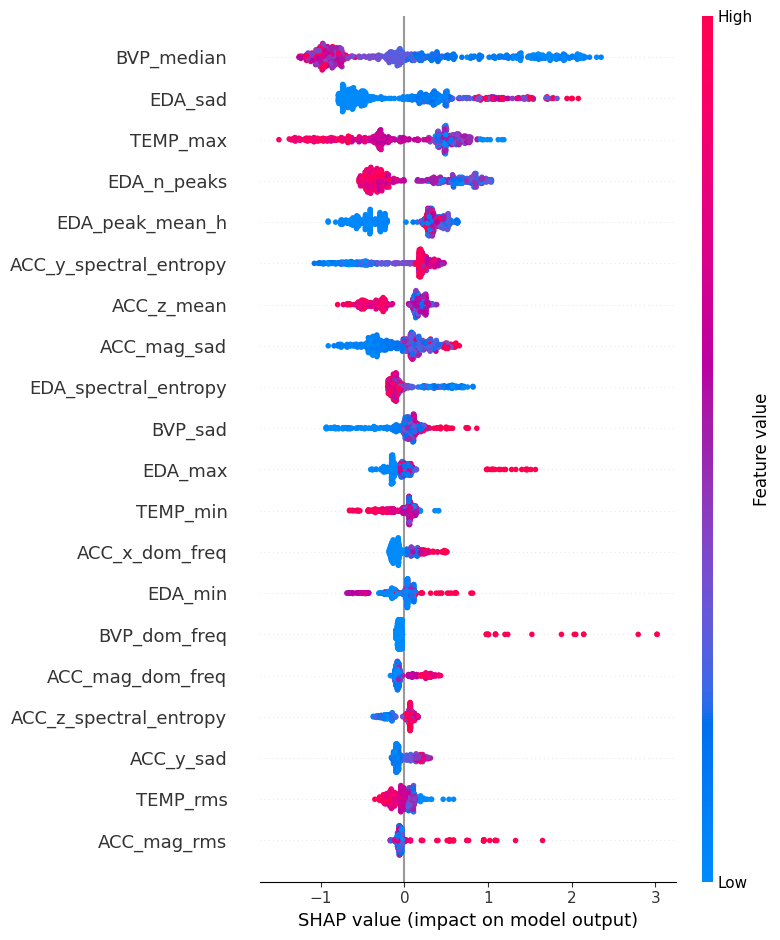

In [23]:

# 2. SHAP Analysis (Explainability)
print("\nCalculating SHAP values for global explainability...")
# Using a subsample for speed
X_sample = shap.utils.sample(X_scaled, 500)
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_sample)
shap.summary_plot(shap_values, features=X_sample, feature_names=X.columns, plot_type="dot")



Analyzing Subject Variability for Top Feature: BVP_median


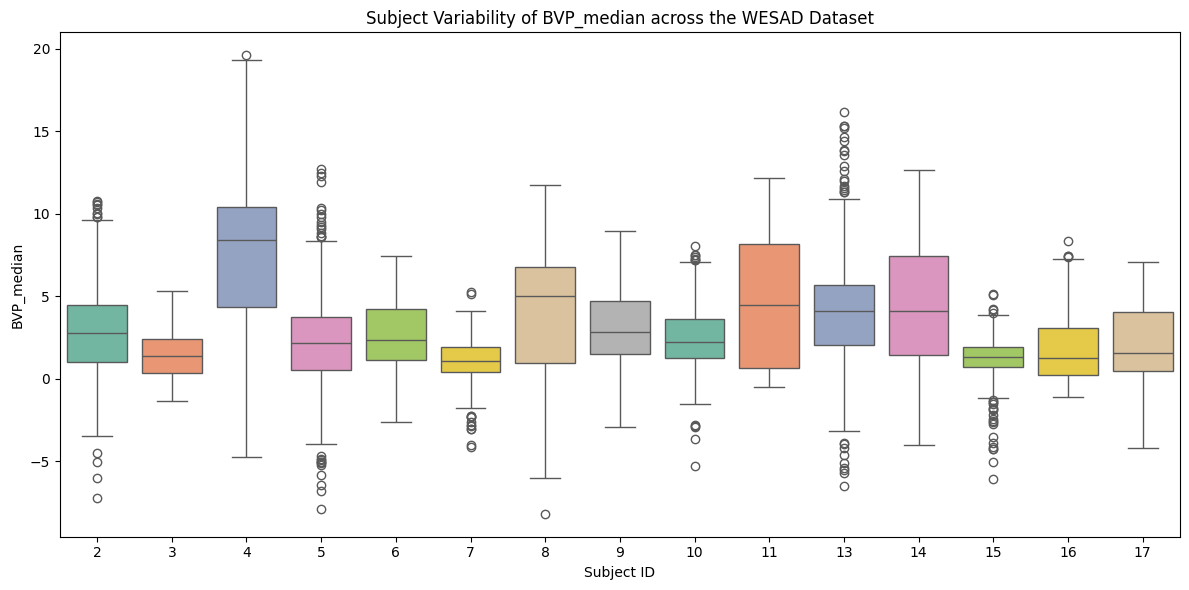

In [24]:


# 3. Subject Variability Plot for Top Feature
print(f"\nAnalyzing Subject Variability for Top Feature: {top_feature_name}")
plt.figure(figsize=(12, 6))
sns.boxplot(x=groups, y=X[top_feature_name], palette='Set2')
plt.title(f"Subject Variability of {top_feature_name} across the WESAD Dataset")
plt.xlabel("Subject ID")
plt.ylabel(top_feature_name)
plt.tight_layout()
plt.show()


## Stacking plots

maybe we have to not use them

STACKING EXPLAINABILITY & FEATURE IMPORTANCE
1. Retraining all base models on the FULL dataset...
2. Retraining Meta-Model on the FULL dataset...

3. Calculating SHAP values for the entire Stacking pipeline...
   (Using KernelExplainer. This might take 1-2 minutes...)


100%|██████████| 300/300 [31:51<00:00,  6.37s/it]


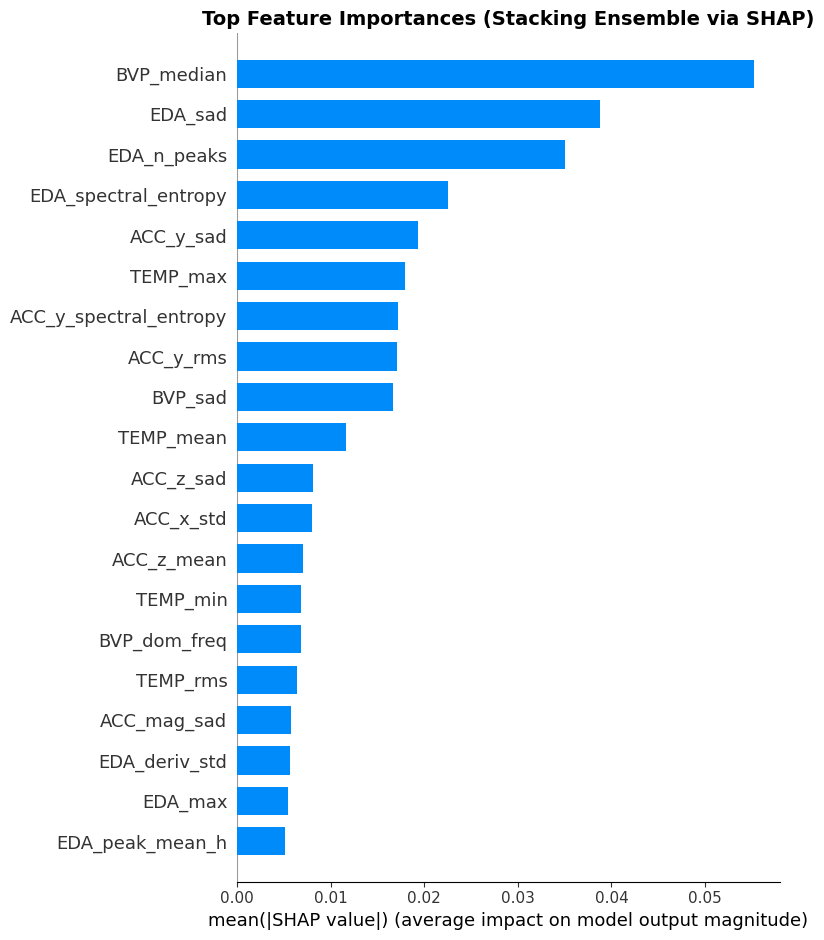

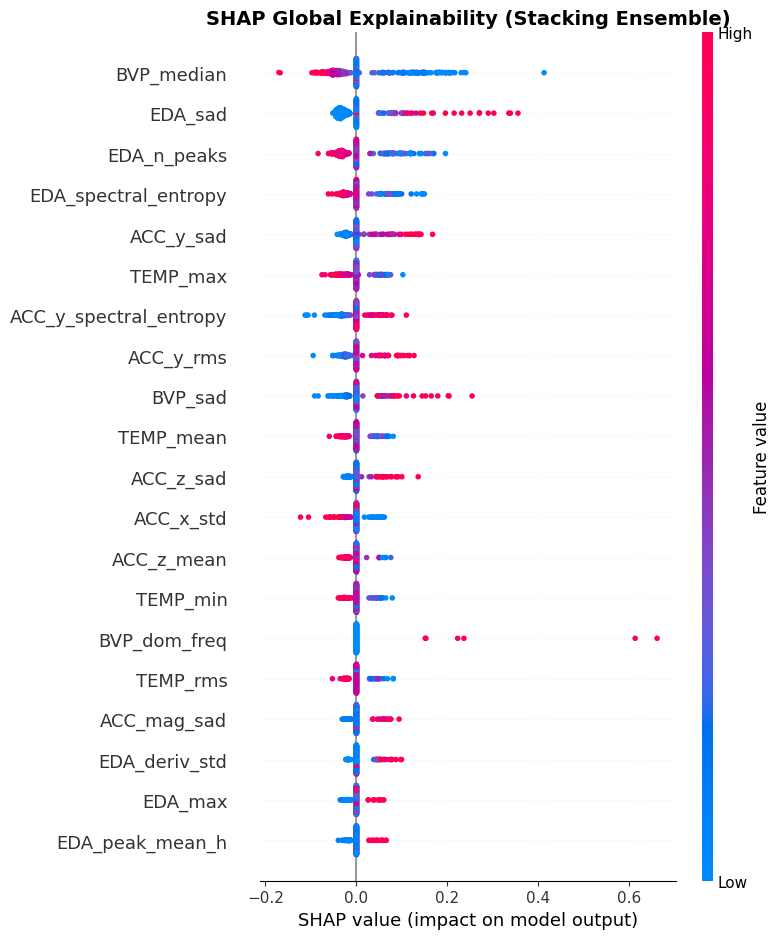


4. Analyzing Subject Variability for Top Feature: BVP_median


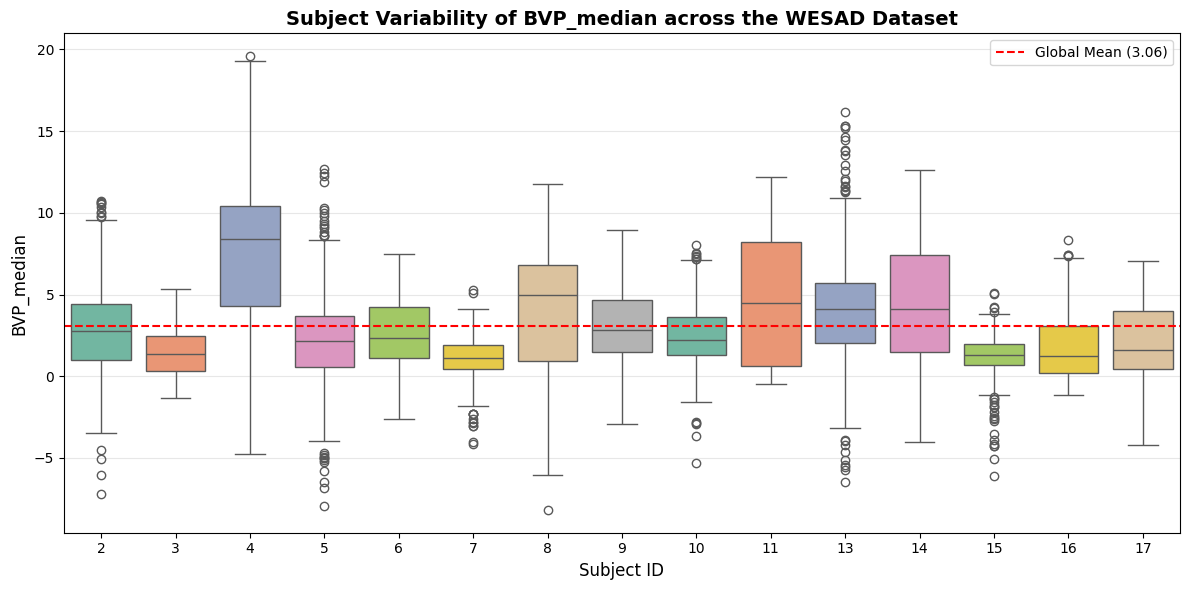

In [25]:
# import shap
# import warnings
# warnings.filterwarnings('ignore')

print("=" * 70)
print("STACKING EXPLAINABILITY & FEATURE IMPORTANCE")
print("=" * 70)

# ==============================================================================
# FASE 0: Addestrare tutto il sistema sull'intero dataset (come nel tuo codice)
# ==============================================================================
print("1. Retraining all base models on the FULL dataset...")
for mname, model in models.items():
    model.fit(X_scaled, y)

print("2. Retraining Meta-Model on the FULL dataset...")
meta_features_full = {}
for mname, model in models.items():
    meta_features_full[mname] = model.predict_proba(X_scaled)[:, 1]

X_meta_full = pd.DataFrame(meta_features_full)
global_meta_model = LogisticRegression(random_state=42, class_weight='balanced')
global_meta_model.fit(X_meta_full, y)

# 3. Creiamo una "Funzione Involucro" (Wrapper) che simula l'intero Stacking
# Prende le 99 feature grezze, le passa ai modelli base, e poi al meta-modello
def full_stacking_predict(X_raw_array):
    meta_X_temp = pd.DataFrame()
    for i, (mname, model) in enumerate(models.items()):
        meta_X_temp[mname] = model.predict_proba(X_raw_array)[:, 1]
    return global_meta_model.predict_proba(meta_X_temp)[:, 1]


# ==============================================================================
# FASE 1 & 2: SHAP Analysis (Sostituisce la Traditional Feature Importance)
# ==============================================================================
print("\n3. Calculating SHAP values for the entire Stacking pipeline...")
print("   (Using KernelExplainer. This might take 1-2 minutes...)")

# Trucco per velocizzare SHAP: usiamo KMeans per riassumere i dati di background
background = shap.kmeans(X_scaled, 25)
explainer = shap.KernelExplainer(full_stacking_predict, background)

# Campioniamo 300 finestre a caso per l'analisi (per non far esplodere il PC)
X_sample_shap = shap.utils.sample(X_scaled, 300)
shap_values = explainer.shap_values(X_sample_shap)

# --- PLOT 1: Traditional Feature Importance (via SHAP Bar Plot) ---
plt.figure(figsize=(10, 6))
plt.title("Top Feature Importances (Stacking Ensemble via SHAP)", fontsize=14, fontweight='bold')
# Il plot a barre di SHAP ordina automaticamente le feature più influenti
shap.summary_plot(shap_values, features=X_sample_shap, feature_names=X.columns, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

# --- PLOT 2: SHAP Summary (Dot Plot) ---
plt.figure(figsize=(10, 6))
plt.title("SHAP Global Explainability (Stacking Ensemble)", fontsize=14, fontweight='bold')
shap.summary_plot(shap_values, features=X_sample_shap, feature_names=X.columns, plot_type="dot", show=False)
plt.tight_layout()
plt.show()


# ==============================================================================
# FASE 3: Subject Variability Plot for Top Feature
# ==============================================================================
# Troviamo la feature numero 1 dinamicamente dai valori SHAP calcolati
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
top_feature_idx = np.argmax(mean_abs_shap)
top_feature_name = X.columns[top_feature_idx]

print(f"\n4. Analyzing Subject Variability for Top Feature: {top_feature_name}")
plt.figure(figsize=(12, 6))
sns.boxplot(x=groups, y=X[top_feature_name], palette='Set2')

# Aggiungiamo una linea per la media globale
global_mean = np.mean(X[top_feature_name])
plt.axhline(global_mean, color='red', linestyle='--', label=f'Global Mean ({global_mean:.2f})')

plt.title(f"Subject Variability of {top_feature_name} across the WESAD Dataset", fontsize=14, fontweight='bold')
plt.xlabel("Subject ID", fontsize=12)
plt.ylabel(top_feature_name, fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Section 9 — Advanced AI / Extensions (Bonus)

In this section, we explore three extensions to the core pipeline:
1. **Feature Selection**: Reducing redundancy using Recursive Feature Elimination (RFE).
2. **Robustness to Noise**: Simulating real-world sensor degradation by adding Gaussian noise.
3. **Personalization Analysis**: Quantifying the "Subject Gap" (General LOSO vs. Personalized models).


In [26]:
from sklearn.feature_selection import RFE

print("Running Recursive Feature Elimination (RFE) to find the best 15 features...")
# Using Gradient Boosting as the estimator for RFE
estimator = GradientBoostingClassifier(n_estimators=50, random_state=42)
selector = RFE(estimator, n_features_to_select=15, step=5)
selector = selector.fit(X_scaled, y)

selected_features = X.columns[selector.support_]
print(f"\nSelected Features:\n{selected_features.tolist()}")

# Evaluate model with selected features only (using LOSO)
X_selected = X[selected_features]
y_true_fs, y_pred_fs = [], []

for train_idx, test_idx in logo.split(X_selected, y, groups):
    X_tr_fs, X_te_fs = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]
    
    m = GradientBoostingClassifier(n_estimators=100, random_state=42)
    m.fit(X_tr_fs, y_tr)
    y_pred_fs.extend(m.predict(X_te_fs))
    y_true_fs.extend(y_te)

fs_f1 = f1_score(y_true_fs, y_pred_fs)
print(f"\nF1-Score with 15 selected features: {fs_f1:.4f}")
print(f"Original F1-Score (all features): {comp_df.loc[comp_df['Model'] == 'Gradient Boosting', 'F1-Score'].values[0]:.4f}")

Running Recursive Feature Elimination (RFE) to find the best 15 features...

Selected Features:
['ACC_y_spectral_entropy', 'ACC_z_mean', 'ACC_z_median', 'ACC_mag_range', 'ACC_mag_rms', 'ACC_mag_sad', 'BVP_median', 'BVP_sad', 'BVP_dom_freq', 'EDA_range', 'EDA_sad', 'EDA_n_peaks', 'EDA_peak_mean_h', 'TEMP_max', 'TEMP_rms']

F1-Score with 15 selected features: 0.8395
Original F1-Score (all features): 0.7713


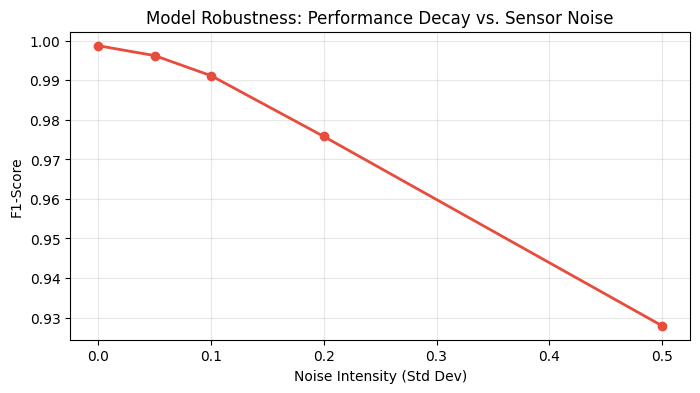

In [27]:
# Simulating real-world sensor artifacts (e.g., loose wristband)
noise_levels = [0, 0.05, 0.1, 0.2, 0.5] 
noise_results = []
best_model_obj = models['Gradient Boosting']

for level in noise_levels:
    X_noisy = X_scaled + np.random.normal(0, level, X_scaled.shape)
    
    # Random split for noise sensitivity baseline
    from sklearn.model_selection import train_test_split
    X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_noisy, y, test_size=0.2, random_state=42)
    
    m = clone(best_model_obj)
    m.fit(X_train_n, y_train_n)
    f1_n = f1_score(y_test_n, m.predict(X_test_n))
    noise_results.append(f1_n)

plt.figure(figsize=(8, 4))
plt.plot(noise_levels, noise_results, marker='o', color='#e74c3c', linewidth=2)
plt.xlabel('Noise Intensity (Std Dev)')
plt.ylabel('F1-Score')
plt.title('Model Robustness: Performance Decay vs. Sensor Noise')
plt.grid(True, alpha=0.3)
plt.show()


General Model (LOSO) F1: 0.7713
Personalized Model (Seen Subjects) F1: 0.9974
Performance Gap: 0.2261


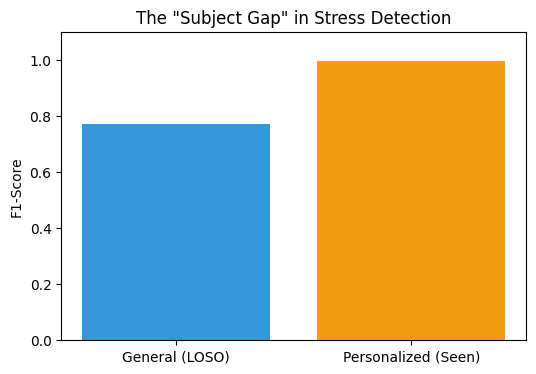

In [28]:
from sklearn.model_selection import StratifiedKFold

# 1. Subject-Independent (LOSO) - General Model
f1_loso = comp_df.loc[comp_df['Model'] == 'Gradient Boosting', 'F1-Score'].values[0]

# 2. Subject-Dependent (Random Split) - Personalized Model
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_scores_dep = []

for train_idx, test_idx in skf.split(X_scaled, y):
    m = clone(best_model_obj)
    m.fit(X_scaled[train_idx], y[train_idx])
    f1_scores_dep.append(f1_score(y[test_idx], m.predict(X_scaled[test_idx])))

f1_dep = np.mean(f1_scores_dep)
print(f"General Model (LOSO) F1: {f1_loso:.4f}")
print(f"Personalized Model (Seen Subjects) F1: {f1_dep:.4f}")
print(f"Performance Gap: {f1_dep - f1_loso:.4f}")

plt.figure(figsize=(6, 4))
plt.bar(['General (LOSO)', 'Personalized (Seen)'], [f1_loso, f1_dep], color=['#3498db', '#f39c12'])
plt.ylabel('F1-Score')
plt.title('The "Subject Gap" in Stress Detection')
plt.ylim(0, 1.1)
plt.show()


Same, but with stacking

 1. RFE & STACKING ENSEMBLE (Top 15 Features)
Running Recursive Feature Elimination (RFE) using Gradient Boosting...

Selected Features:
['ACC_y_spectral_entropy', 'ACC_z_mean', 'ACC_z_median', 'ACC_mag_range', 'ACC_mag_rms', 'ACC_mag_sad', 'BVP_median', 'BVP_sad', 'BVP_dom_freq', 'EDA_range', 'EDA_sad', 'EDA_n_peaks', 'EDA_peak_mean_h', 'TEMP_max', 'TEMP_rms']

Evaluating Stacking Ensemble on the 15 selected features (LOSO)...
(Please wait, training the ensemble takes time...)
-> F1-Score of Stacking with 15 selected features: 0.8612
-> Original F1-Score of Stacking (99 features): 0.8050

 2. THE 'SUBJECT GAP' USING STACKING ENSEMBLE
Running Subject-Dependent validation (5-Fold CV)...

General Model (LOSO) F1: 0.8050
Personalized Model (Seen Subjects) F1: 0.9882
Performance Gap: 0.1832


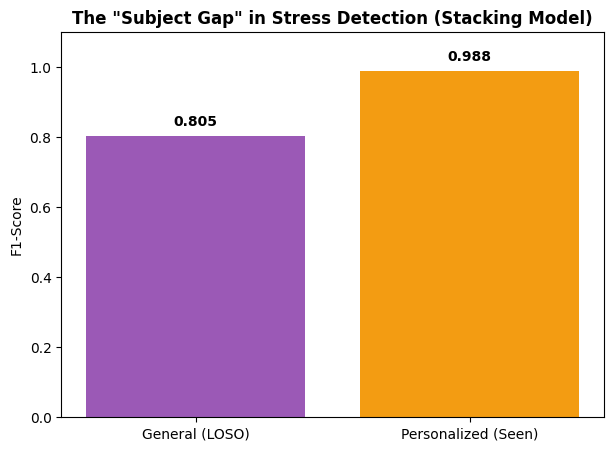

In [29]:
print("=" * 70)
print(" 1. RFE & STACKING ENSEMBLE (Top 15 Features)")
print("=" * 70)

# Use gradneint Boostinf for find the 15 features
print("Running Recursive Feature Elimination (RFE) using Gradient Boosting...")
estimator_rfe = GradientBoostingClassifier(n_estimators=50, random_state=42)
selector = RFE(estimator_rfe, n_features_to_select=15, step=5)
selector = selector.fit(X_scaled, y)

selected_features = X.columns[selector.support_]
print(f"\nSelected Features:\n{selected_features.tolist()}")

X_selected = X[selected_features]

# Real Stacking classfier
base_estimators = [
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ('svm', SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)),
    ('mlp', MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, early_stopping=True, random_state=42))
]
stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(class_weight='balanced', random_state=42),
    cv=5
)

# LOSO on the 15 features
print("\nEvaluating Stacking Ensemble on the 15 selected features (LOSO)...")
print("(Please wait, training the ensemble takes time...)")
y_true_fs, y_pred_fs = [], []

for train_idx, test_idx in logo.split(X_selected, y, groups):
    X_tr_fs, X_te_fs = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]
    
    # Imptute and scale
    imp_fs = SimpleImputer(strategy='median')
    sca_fs = StandardScaler()
    X_tr_s = sca_fs.fit_transform(imp_fs.fit_transform(X_tr_fs))
    X_te_s = sca_fs.transform(imp_fs.transform(X_te_fs))
    
    m_stack = clone(stacking_clf)
    m_stack.fit(X_tr_s, y_tr)
    y_pred_fs.extend(m_stack.predict(X_te_s))
    y_true_fs.extend(y_te)

fs_f1_stack = f1_score(y_true_fs, y_pred_fs)
print(f"-> F1-Score of Stacking with 15 selected features: {fs_f1_stack:.4f}")
print(f"-> Original F1-Score of Stacking (99 features): {f1_stack:.4f}")


print("\n" + "=" * 70)
print(" 2. THE 'SUBJECT GAP' USING STACKING ENSEMBLE")
print("=" * 70)

# We take the General Model (LOSO) from the one calculated earlier based on the 99 features
f1_loso_stack = f1_stack 

# Personalized Model
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_scores_dep_stack = []

print("Running Subject-Dependent validation (5-Fold CV)...")
for train_idx, test_idx in skf.split(X_scaled, y):
    m_dep = clone(stacking_clf)
    m_dep.fit(X_scaled[train_idx], y[train_idx])
    preds_dep = m_dep.predict(X_scaled[test_idx])
    f1_scores_dep_stack.append(f1_score(y[test_idx], preds_dep))

f1_dep_stack = np.mean(f1_scores_dep_stack)

print(f"\nGeneral Model (LOSO) F1: {f1_loso_stack:.4f}")
print(f"Personalized Model (Seen Subjects) F1: {f1_dep_stack:.4f}")
print(f"Performance Gap: {f1_dep_stack - f1_loso_stack:.4f}")

# Plot
plt.figure(figsize=(7, 5))
bars = plt.bar(['General (LOSO)', 'Personalized (Seen)'], [f1_loso_stack, f1_dep_stack], color=['#9b59b6', '#f39c12'])
plt.ylabel('F1-Score')
plt.title('The "Subject Gap" in Stress Detection (Stacking Model)', fontweight='bold')
plt.ylim(0, 1.1)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.3f}", ha='center', va='bottom', fontweight='bold')

plt.show()

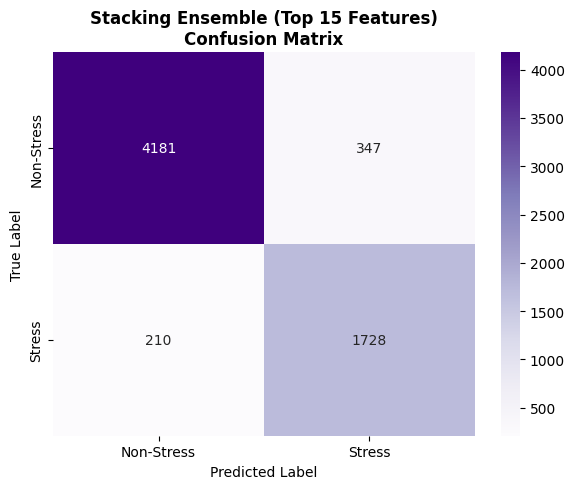


--- Classification Report (Stacking with 15 Features) ---
              precision    recall  f1-score   support

  Non-Stress       0.95      0.92      0.94      4528
      Stress       0.83      0.89      0.86      1938

    accuracy                           0.91      6466
   macro avg       0.89      0.91      0.90      6466
weighted avg       0.92      0.91      0.91      6466



In [ ]:
# confusion matrix using the results saved in the LOSO loop
cm_fs = confusion_matrix(y_true_fs, y_pred_fs)

# Creiamo il grafico
plt.figure(figsize=(6, 5))
sns.heatmap(cm_fs, annot=True, fmt='d', cmap='Purples', 
            xticklabels=BINARY_LABEL_NAMES, yticklabels=BINARY_LABEL_NAMES)

plt.title('Stacking Ensemble (Top 15 Features)\nConfusion Matrix', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=10)
plt.xlabel('Predicted Label', fontsize=10)
plt.tight_layout()
plt.show()

print("\n--- Classification Report (Stacking with 15 Features) ---")
print(classification_report(y_true_fs, y_pred_fs, target_names=BINARY_LABEL_NAMES))

### 9.4 Potential Deep Learning Approach: "Can we apply more advanced AI techniques?"

**Yes, Deep Learning architectures could significantly enhance this pipeline.**
Currently, our approach relies on *hand-crafted features* (e.g., statistical moments, frequency power, peak detection) extracted from 5-second windows. While effective and computationally light, this method might miss complex, non-linear temporal patterns hidden in the raw physiological signals.

If we were to apply more advanced AI techniques, two approaches stand out:
1. **1D Convolutional Neural Networks (1D-CNNs):** Instead of manually extracting features, we could feed the raw signal windows directly into a 1D-CNN. The convolutional filters would act as automated feature extractors, learning optimal spatial and frequency-domain representations directly from the Empatica E4 data.
2. **Long Short-Term Memory Networks (LSTMs):** Physiological responses to stress are highly time-dependent (e.g., EDA has a slow recovery rate after a stressor). By framing the problem as a sequence classification task, an LSTM could process a rolling sequence of windows. This would allow the model to maintain a "memory" of the subject's baseline state, adapting dynamically to changes over time and potentially reducing the "Subject Gap" observed above.

In [30]:
# === 9.4 Conceptual Deep Learning Architecture (LSTM) ===
# Note: To fully train this, the 2D feature matrix X would need to be 
# reshaped into 3D sequences: (samples, timesteps, features) using a sliding window.

import warnings
warnings.filterwarnings('ignore')

try:
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
    
    def build_lstm_stress_model(timesteps, num_features):
        """
        Builds a conceptual LSTM network for sequential stress detection.
        """
        model = Sequential([
            # First LSTM layer to capture temporal dependencies in physiological signals
            LSTM(64, return_sequences=True, input_shape=(timesteps, num_features)),
            BatchNormalization(),
            Dropout(0.3),
            
            # Second LSTM layer for deeper abstraction
            LSTM(32, return_sequences=False),
            BatchNormalization(),
            Dropout(0.3),
            
            # Fully connected layer
            Dense(16, activation='relu'),
            
            # Output layer for binary classification (Stress vs Non-Stress)
            Dense(1, activation='sigmoid')
        ])
        
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        return model
    
    # Let's instantiate and print the summary of the conceptual model.
    # Assuming we want the model to "look back" at a sequence of 10 windows (timesteps = 10)
    timesteps_example = 10
    num_features_example = X_scaled.shape[1]
    
    dl_model = build_lstm_stress_model(timesteps=timesteps_example, num_features=num_features_example)
    print("Conceptual LSTM Architecture defined successfully.\n")
    dl_model.summary()

except ImportError:
    print("TensorFlow/Keras is not installed in this environment.")
    print("This conceptual code block requires TensorFlow to display the model summary.")
    print("Architecture: 2 stacked LSTM layers followed by Dense layers for binary classification.")

TensorFlow/Keras is not installed in this environment.
This conceptual code block requires TensorFlow to display the model summary.
Architecture: 2 stacked LSTM layers followed by Dense layers for binary classification.



Section 10 — SoA Analysis & Critical Discussion
State-of-the-art analysis
Data access & quality considerations
Explainability discussion
Ethical considerations & GDPR
Challenges of AI in healthcare
Journal club checklist integration